# Where Do Tech Professionals Spend Their Salary?
## Survey results analysis (75 respondents)

Exploratory analysis of financial satisfaction and spending patterns among
data / analytics professionals. The raw survey data stays in Russian
(direct respondent answers), while all chart labels, titles and wordcloud
captions are in English. Wordcloud contents themselves are kept in Russian
because they're authentic respondent phrasings — see `README.md` for a
translation of the top terms.

**Salary convention.** All salary figures in this notebook are **monthly
net (take-home) RUB**, i.e. what respondents receive after Russian income
tax (13–15% for residents) and other deductions. This is how salaries
are quoted in the Russian tech market, and differs from the Western
convention of annual gross. For rough reference: 300k RUB/month net ≈
3.6M RUB/year net ≈ 4.14M RUB/year gross at 13% tax.

In [1]:
import os
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from wordcloud import WordCloud

warnings.filterwarnings('ignore')

# All charts are written to this folder
CHARTS_DIR = 'charts'
os.makedirs(CHARTS_DIR, exist_ok=True)

# ── Color palette ──
BG       = '#0f0f0f'
CARD_BG  = '#1a1a2e'
ACCENT1  = '#e94560'  # red-pink
ACCENT2  = '#0f3460'  # dark blue
ACCENT3  = '#533483'  # purple
TEXT     = '#e0e0e0'
TEXT_DIM = '#888888'
GRID     = '#2a2a3a'

PALETTE = ['#e94560', '#f5a623', '#7b68ee', '#00d2d3', '#ff6b6b',
           '#48dbfb', '#ff9ff3', '#54a0ff', '#5f27cd', '#01a3a4',
           '#c44569', '#f8b500', '#6c5ce7', '#00cec9', '#fd79a8']

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 12,
    'figure.facecolor': BG,
    'axes.facecolor': CARD_BG,
    'axes.edgecolor': GRID,
    'axes.labelcolor': TEXT,
    'text.color': TEXT,
    'xtick.color': TEXT_DIM,
    'ytick.color': TEXT_DIM,
    'grid.color': GRID,
    'grid.alpha': 0.3,
    'figure.dpi': 150,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'savefig.facecolor': BG,
    'savefig.pad_inches': 0.3,
})

print("Style loaded ✓")

Style loaded ✓


In [2]:
# ── Load and prepare data ──
df = pd.read_csv('survey_data.csv')

df.columns = ['timestamp', 'position', 'age', 'grade', 'salary',
              'extra_income', 'comfort', 'new_purchases',
              'tech_purchase', 'salary_dissolves', 'cushion', 'top_expenses']

# Raw categorical values (kept in original Russian as they appear in the CSV)
salary_order = ['<100к', '100к-150к', '151к-200к', '201к-250к', '251к-300к',
                '301к-350к', '351к-400к', '401к-450к', '501к +']
salary_mid = {'<100к': 75, '100к-150к': 125, '151к-200к': 175, '201к-250к': 225,
              '251к-300к': 275, '301к-350к': 325, '351к-400к': 375,
              '401к-450к': 425, '501к +': 550}

grade_order = ['Intern/Trainee/Стажёр', 'Junior', 'Middle', 'Senior', 'Lead', 'Head/Principal']
age_order = ['19-22', '23-26', '27-30', '31+']
cushion_order = ['Нет', '< 1 месяца', '1-3 месяца', '4-6 месяцев',
                 '7-12 месяцев', '1 год +']

# English display labels — applied only for chart titles / tick labels
SALARY_LABEL = {
    '<100к': '<100k', '100к-150к': '100–150k', '151к-200к': '151–200k',
    '201к-250к': '201–250k', '251к-300к': '251–300k', '301к-350к': '301–350k',
    '351к-400к': '351–400k', '401к-450к': '401–450k', '501к +': '501k+',
}
GRADE_LABEL = {
    'Intern/Trainee/Стажёр': 'Intern',
    'Junior': 'Junior', 'Middle': 'Middle',
    'Senior': 'Senior', 'Lead': 'Lead', 'Head/Principal': 'Head',
}
CUSHION_LABEL = {
    'Нет': 'None', '< 1 месяца': '< 1 month',
    '1-3 месяца': '1–3 months', '4-6 месяцев': '4–6 months',
    '7-12 месяцев': '7–12 months', '1 год +': '1 year+',
}
YESNO = {'Да': 'Yes', 'Нет': 'No'}

EXPENSE_LABEL = {
    'Еда, в т.ч. рестораны': 'Food & restaurants',
    'Аренда жилья': 'Rent',
    'Инвестиции / накопления': 'Investments / savings',
    'Путешествия': 'Travel',
    'Содержу семью (партнёр и/или дети)': 'Family (partner/kids)',
    'Здоровье / спорт': 'Health / sports',
    'Помогаю родителям / родственникам': 'Helping relatives',
    'Ипотека': 'Mortgage',
    'Образование': 'Education',
    'Транспорт': 'Transport',
    'Живу заграницей': 'Living abroad',
    'Гаджеты / техника': 'Gadgets / tech',
    'Другие кредиты': 'Other loans',
    'Ремонт': 'Home renovation',
}

df['salary_cat'] = pd.Categorical(df['salary'], categories=salary_order, ordered=True)
df['grade_cat'] = pd.Categorical(df['grade'], categories=grade_order, ordered=True)
df['age_cat'] = pd.Categorical(df['age'], categories=age_order, ordered=True)
df['cushion_cat'] = pd.Categorical(df['cushion'], categories=cushion_order, ordered=True)
df['salary_num'] = df['salary'].map(salary_mid)

print(f"Loaded {len(df)} responses ✓")
df[['position', 'age', 'grade', 'salary', 'comfort']].head()

Loaded 75 responses ✓


,position,age,grade,salary,comfort
0,Data аналитик,23-26,Junior,100к-150к,7
1,Data аналитик,19-22,Middle,251к-300к,7
2,Data аналитик,31+,Middle,100к-150к,4
3,Продуктовый аналитик,23-26,Senior,351к-400к,6
4,Продуктовый аналитик,19-22,Middle,201к-250к,6


---
## 1. More money = more happiness?
Salary vs. self-reported financial comfort

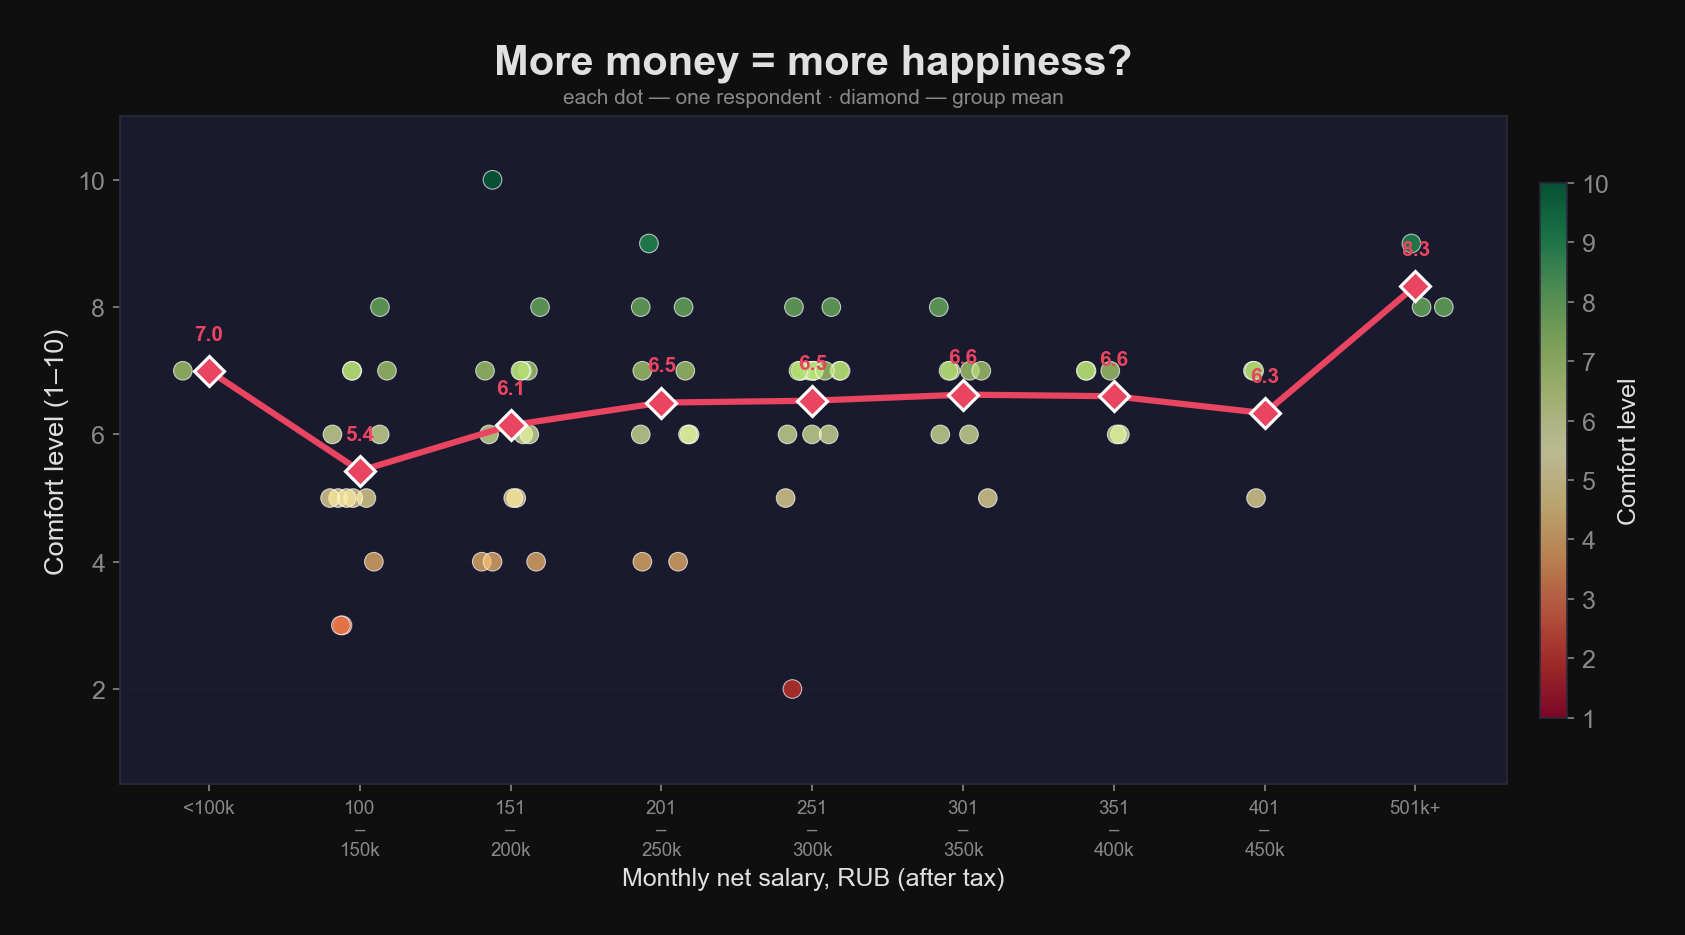

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

grouped = df.groupby('salary_cat', observed=False)['comfort']
means = grouped.mean()

np.random.seed(42)
x_pos = df['salary_cat'].cat.codes.values
jitter = np.random.uniform(-0.2, 0.2, len(x_pos))
scatter = ax.scatter(x_pos + jitter, df['comfort'],
                     c=df['comfort'], cmap='RdYlGn',
                     s=80, alpha=0.7, edgecolors='white', linewidth=0.5,
                     vmin=1, vmax=10, zorder=3)

# Mean line
valid = means.dropna()
ax.plot(valid.index.codes, valid.values, color=ACCENT1, linewidth=3,
        zorder=4, marker='D', markersize=10, markeredgecolor='white', markeredgewidth=1.5)

# Annotate means
for idx, val in zip(valid.index.codes, valid.values):
    ax.annotate(f'{val:.1f}', (idx, val), textcoords="offset points",
                xytext=(0, 15), ha='center', fontsize=10, fontweight='bold',
                color=ACCENT1)

ax.set_xticks(range(len(salary_order)))
ax.set_xticklabels([SALARY_LABEL[s].replace('–', '\n–\n') for s in salary_order], fontsize=9)
ax.set_xlabel('Monthly net salary, RUB (after tax)', fontsize=12)
ax.set_ylabel('Comfort level (1–10)', fontsize=13)
ax.set_ylim(0.5, 11)
ax.set_title('More money = more happiness?', fontsize=20, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'each dot — one respondent · diamond — group mean',
        transform=ax.transAxes, ha='center', fontsize=10, color=TEXT_DIM)
ax.grid(axis='y', alpha=0.2)

plt.colorbar(scatter, ax=ax, label='Comfort level', shrink=0.8, pad=0.02)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/01_money_vs_happiness.png')
plt.show()

---
## 2. Where does the money go?
Top expense categories

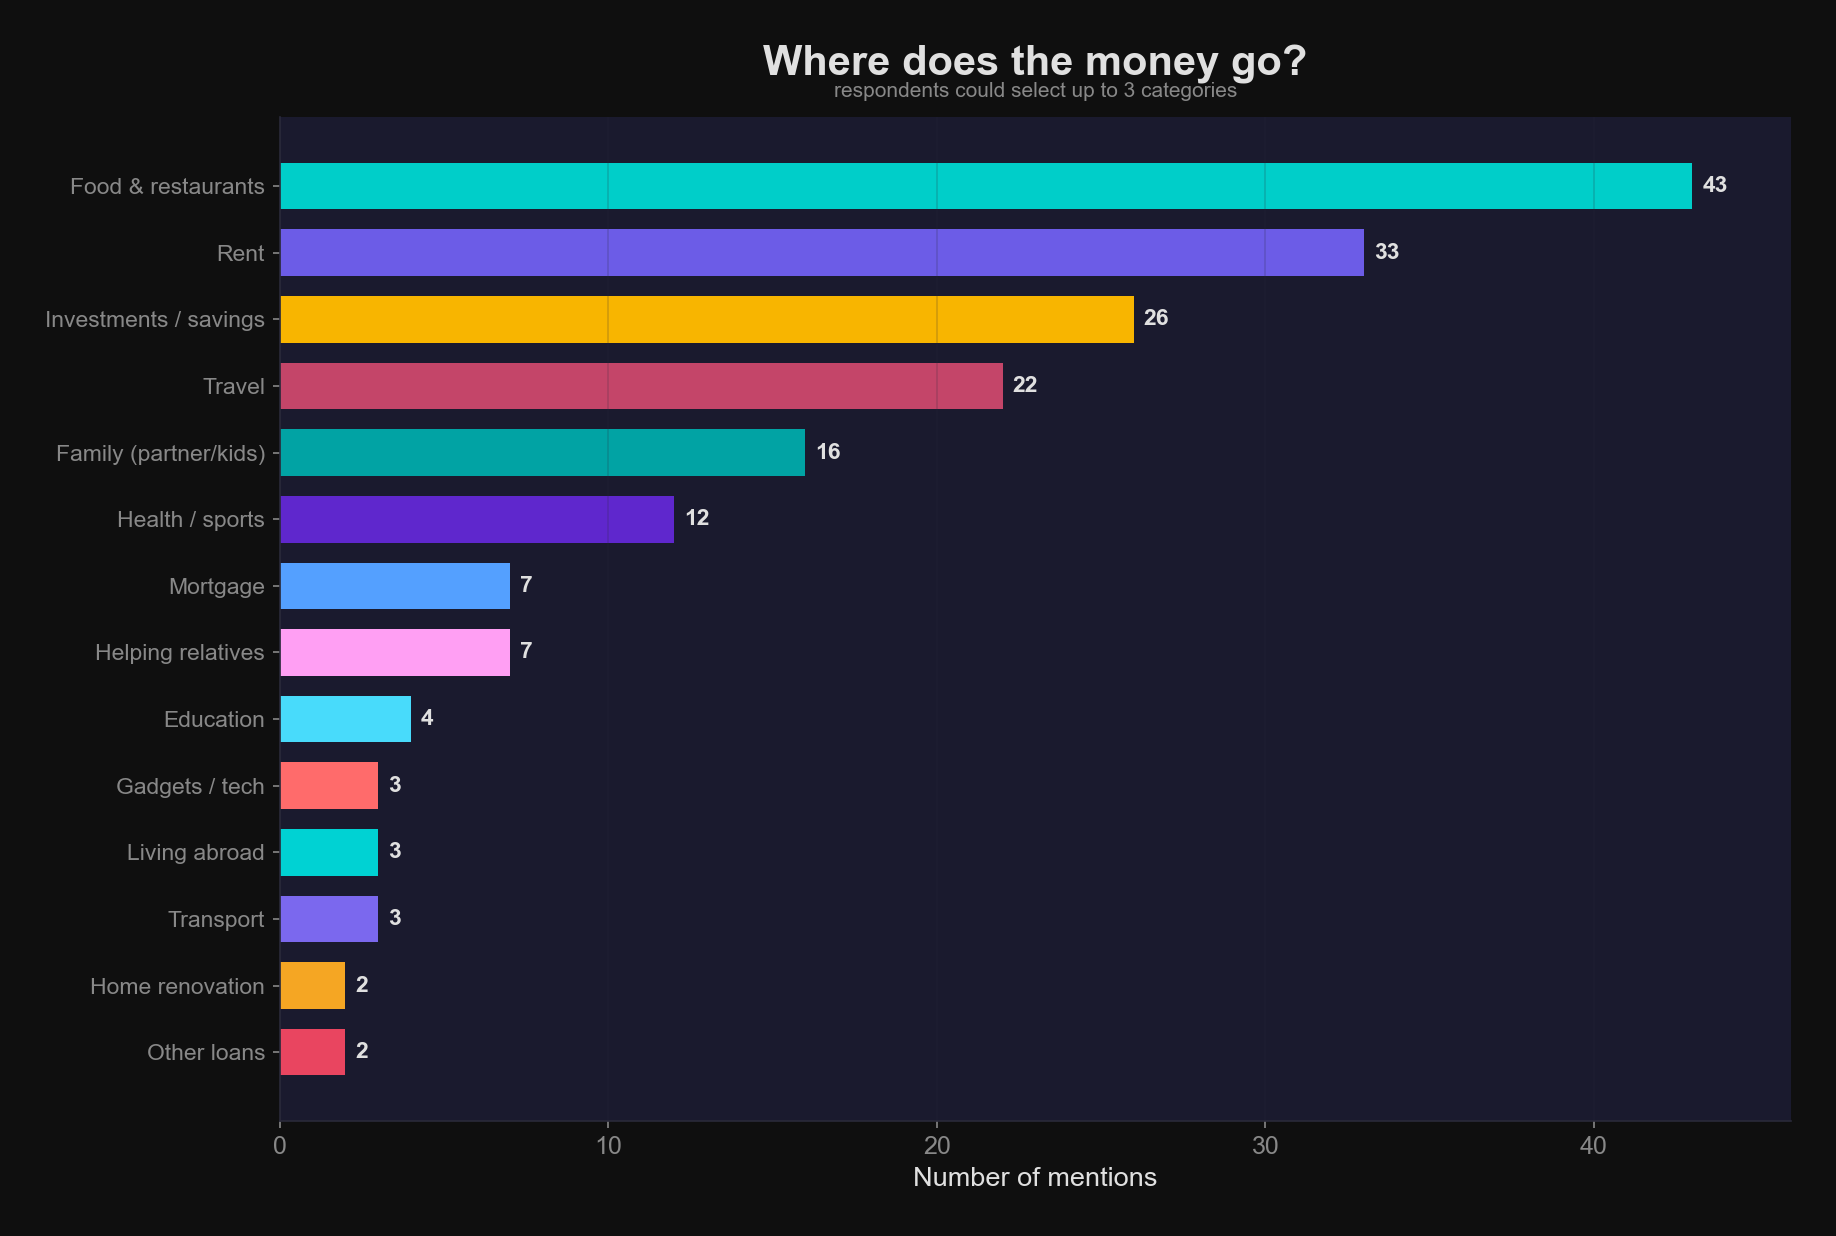

In [4]:
# Parse multi-select answers
all_expenses = []
for row in df['top_expenses'].dropna():
    all_expenses.extend(item.strip() for item in row.split(';'))

expense_counts = Counter(all_expenses)
# Drop one-offs (< 2 mentions)
expense_counts = {k: v for k, v in expense_counts.items() if v >= 2}
exp_df = pd.DataFrame.from_dict(expense_counts, orient='index', columns=['count'])
exp_df = exp_df.sort_values('count', ascending=True)
exp_df.index = [EXPENSE_LABEL.get(c, c) for c in exp_df.index]

fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(range(len(exp_df)), exp_df['count'],
        color=[PALETTE[i % len(PALETTE)] for i in range(len(exp_df))],
        edgecolor='none', height=0.7)

for i, val in enumerate(exp_df['count']):
    ax.text(val + 0.3, i, str(val), va='center', fontsize=11, fontweight='bold', color=TEXT)

ax.set_yticks(range(len(exp_df)))
ax.set_yticklabels(exp_df.index, fontsize=11)
ax.set_xlabel('Number of mentions', fontsize=13)
ax.set_title('Where does the money go?', fontsize=20, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'respondents could select up to 3 categories',
        transform=ax.transAxes, ha='center', fontsize=10, color=TEXT_DIM)
ax.set_xlim(0, exp_df['count'].max() + 3)
ax.grid(axis='x', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/02_top_expenses.png')
plt.show()

---
## 3. "Salary dissolves" — who feels it?
Feeling breakdown by grade and salary band

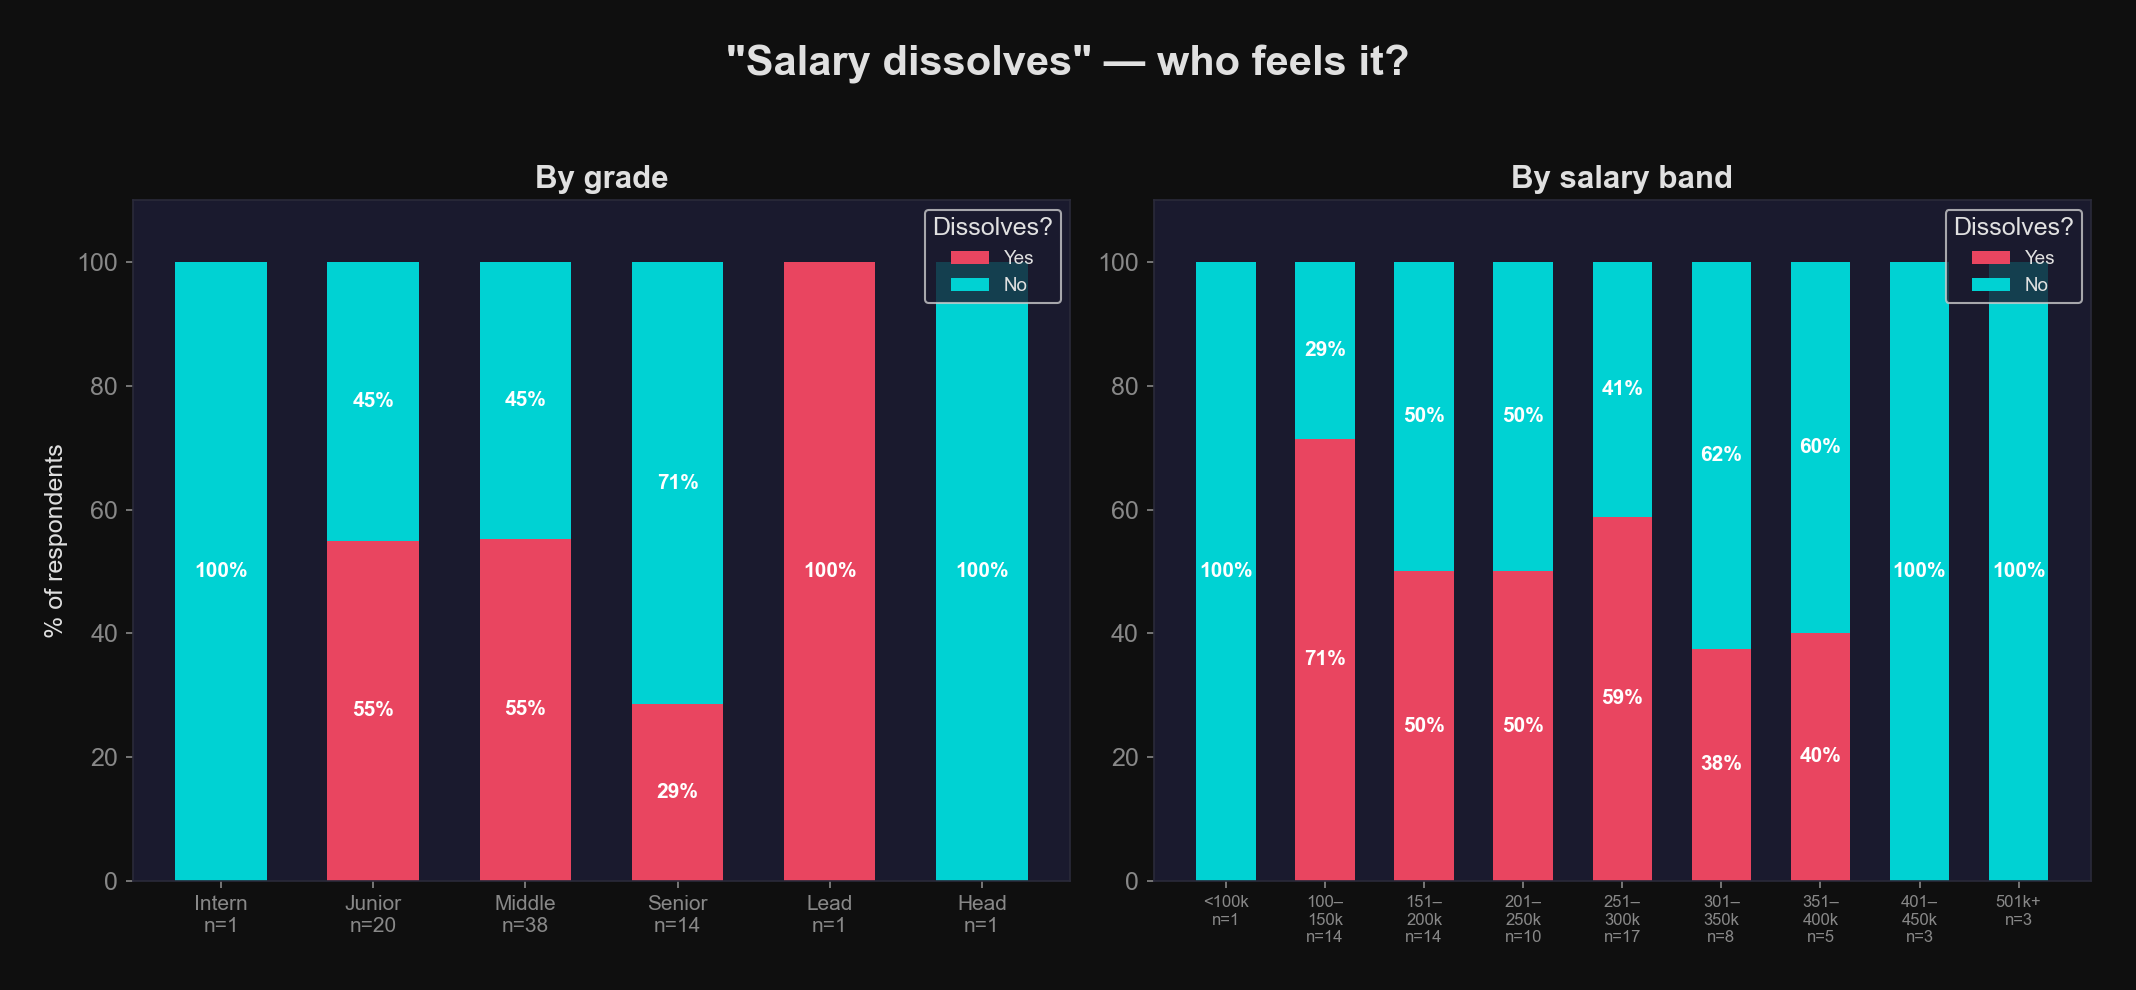

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ── By grade ──
ct_grade = pd.crosstab(df['grade_cat'], df['salary_dissolves'], normalize='index') * 100
grades_present = [g for g in grade_order if g in ct_grade.index]
ct_grade = ct_grade.loc[grades_present]
grade_counts = df['grade_cat'].value_counts()

colors_yn = [ACCENT1, '#00d2d3']
bottom = np.zeros(len(ct_grade))
for i, col in enumerate(['Да', 'Нет']):
    if col in ct_grade.columns:
        vals = ct_grade[col].values
        ax1.bar(range(len(ct_grade)), vals, bottom=bottom,
                color=colors_yn[i], label=YESNO[col], edgecolor='none', width=0.6)
        for j, v in enumerate(vals):
            if v > 8:
                ax1.text(j, bottom[j] + v/2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=10, fontweight='bold', color='white')
        bottom += vals

ax1.set_xticks(range(len(ct_grade)))
ax1.set_xticklabels(
    [f'{GRADE_LABEL[g]}\nn={grade_counts.get(g, 0)}' for g in grades_present],
    fontsize=10)
ax1.set_ylabel('% of respondents', fontsize=12)
ax1.set_title('By grade', fontsize=15, fontweight='bold')
ax1.legend(title='Dissolves?', loc='upper right', fontsize=9)
ax1.set_ylim(0, 110)

# ── By salary ──
ct_salary = pd.crosstab(df['salary_cat'], df['salary_dissolves'], normalize='index') * 100
sals_present = [s for s in salary_order if s in ct_salary.index]
ct_salary = ct_salary.loc[sals_present]
salary_counts = df['salary_cat'].value_counts()

bottom2 = np.zeros(len(ct_salary))
for i, col in enumerate(['Да', 'Нет']):
    if col in ct_salary.columns:
        vals = ct_salary[col].values
        ax2.bar(range(len(ct_salary)), vals, bottom=bottom2,
                color=colors_yn[i], label=YESNO[col], edgecolor='none', width=0.6)
        for j, v in enumerate(vals):
            if v > 8:
                ax2.text(j, bottom2[j] + v/2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=10, fontweight='bold', color='white')
        bottom2 += vals

ax2.set_xticks(range(len(ct_salary)))
ax2.set_xticklabels(
    [SALARY_LABEL[s].replace('–', '–\n') + f'\nn={salary_counts.get(s, 0)}' for s in sals_present],
    fontsize=8)
ax2.set_title('By salary band', fontsize=15, fontweight='bold')
ax2.legend(title='Dissolves?', loc='upper right', fontsize=9)
ax2.set_ylim(0, 110)

fig.suptitle('"Salary dissolves" — who feels it?', fontsize=20, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/03_salary_dissolves.png')
plt.show()

---
## 4. Emergency fund
Distribution of financial cushion by grade

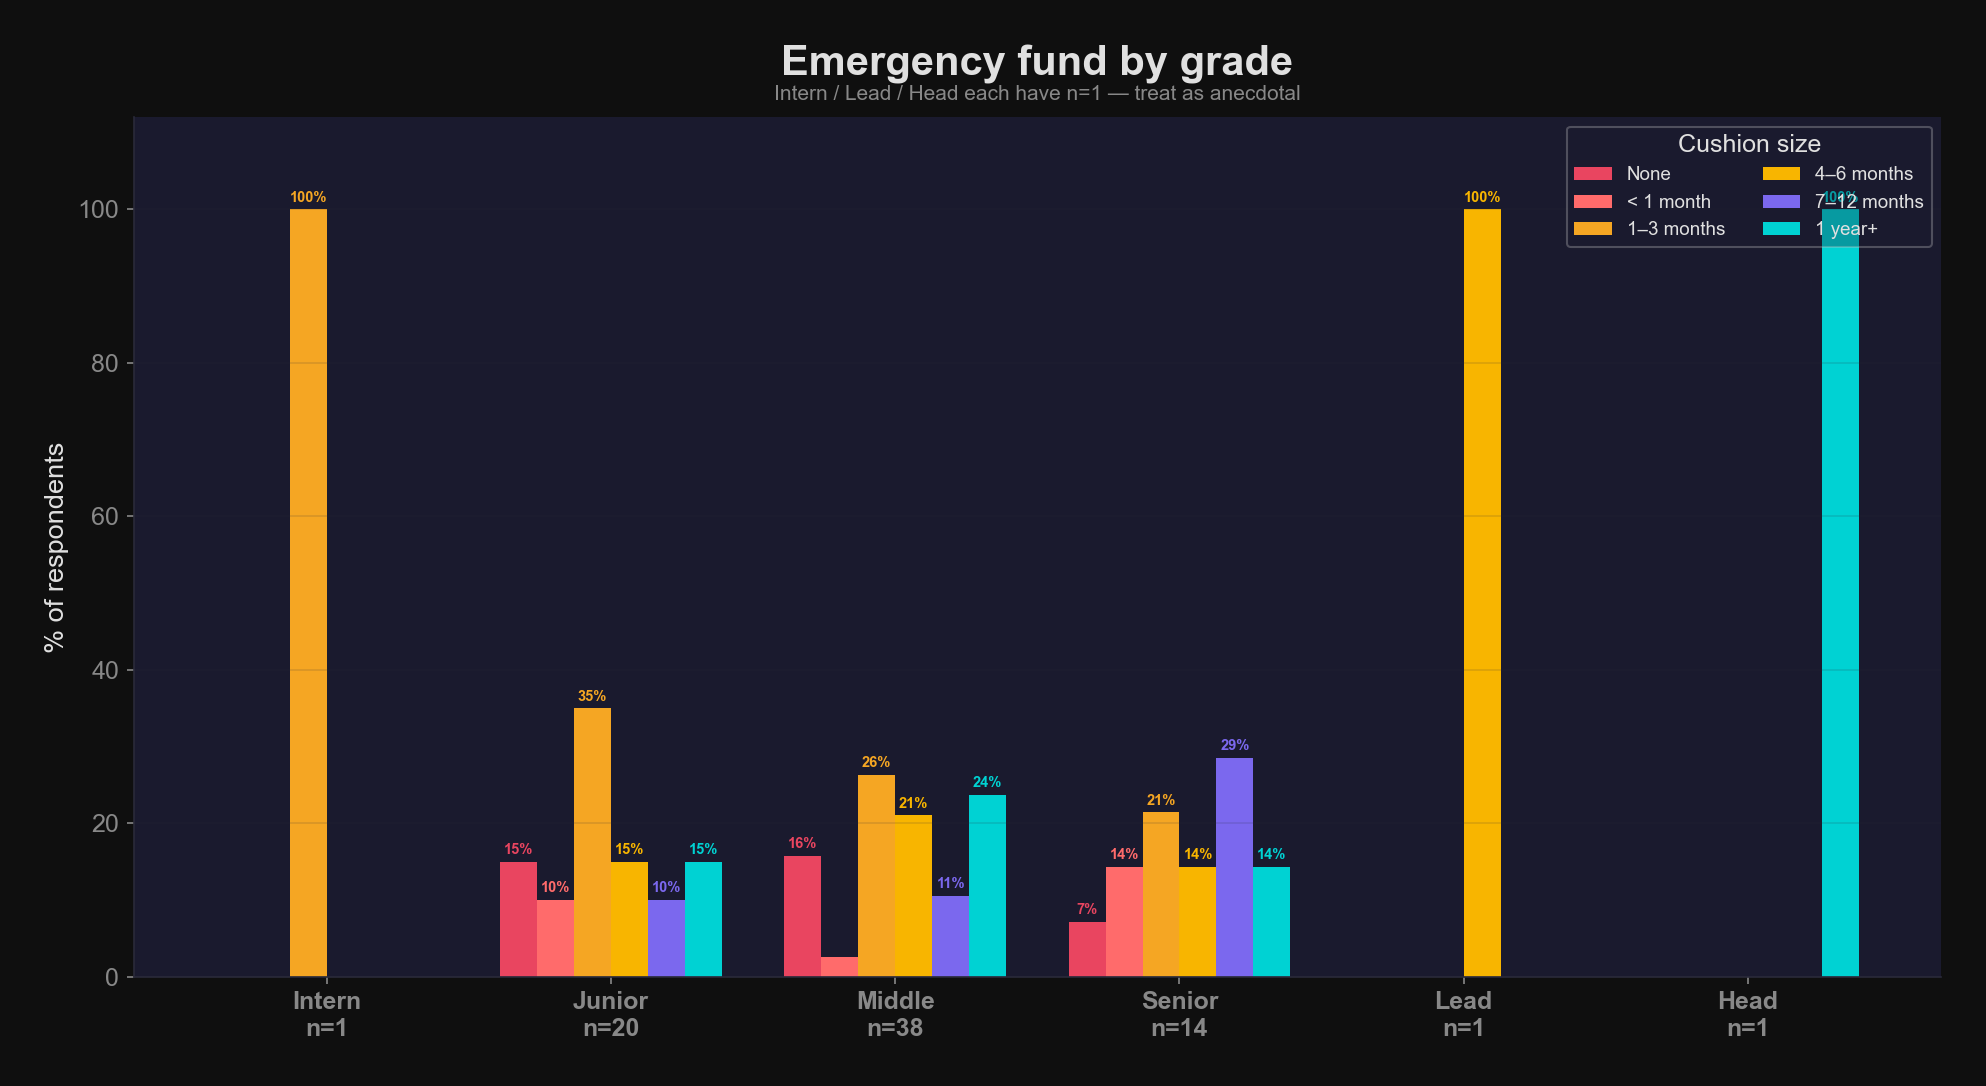

In [6]:
fig, ax = plt.subplots(figsize=(13, 7))

ct = pd.crosstab(df['grade_cat'], df['cushion_cat'], normalize='index') * 100
grades_present = [g for g in grade_order if g in ct.index]
ct = ct.loc[grades_present]
grade_counts = df['grade_cat'].value_counts()

# Colors from red (none) → teal (1 year+)
cushion_colors = ['#e94560', '#ff6b6b', '#f5a623', '#f8b500', '#7b68ee', '#00d2d3']

x = np.arange(len(grades_present))
width = 0.13

for i, cushion in enumerate(cushion_order):
    if cushion in ct.columns:
        vals = ct[cushion].values
        ax.bar(x + i * width - width * 2.5, vals, width,
               label=CUSHION_LABEL[cushion], color=cushion_colors[i], edgecolor='none')
        for j, v in enumerate(vals):
            if v > 5:
                ax.text(x[j] + i * width - width * 2.5, v + 1, f'{v:.0f}%',
                       ha='center', fontsize=7, fontweight='bold', color=cushion_colors[i])

ax.set_xticks(x)
ax.set_xticklabels(
    [f'{GRADE_LABEL[g]}\nn={grade_counts.get(g, 0)}' for g in grades_present],
    fontsize=12, fontweight='bold')
ax.set_ylabel('% of respondents', fontsize=13)
ax.set_title('Emergency fund by grade', fontsize=20, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Intern / Lead / Head each have n=1 — treat as anecdotal',
        transform=ax.transAxes, ha='center', fontsize=10, color=TEXT_DIM)
ax.legend(title='Cushion size', loc='upper right', fontsize=9,
          ncol=2, framealpha=0.3)
ax.grid(axis='y', alpha=0.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, ct.max().max() + 12)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/04_emergency_fund.png')
plt.show()

---
## 5. Salary by grade
Salary distribution within each grade

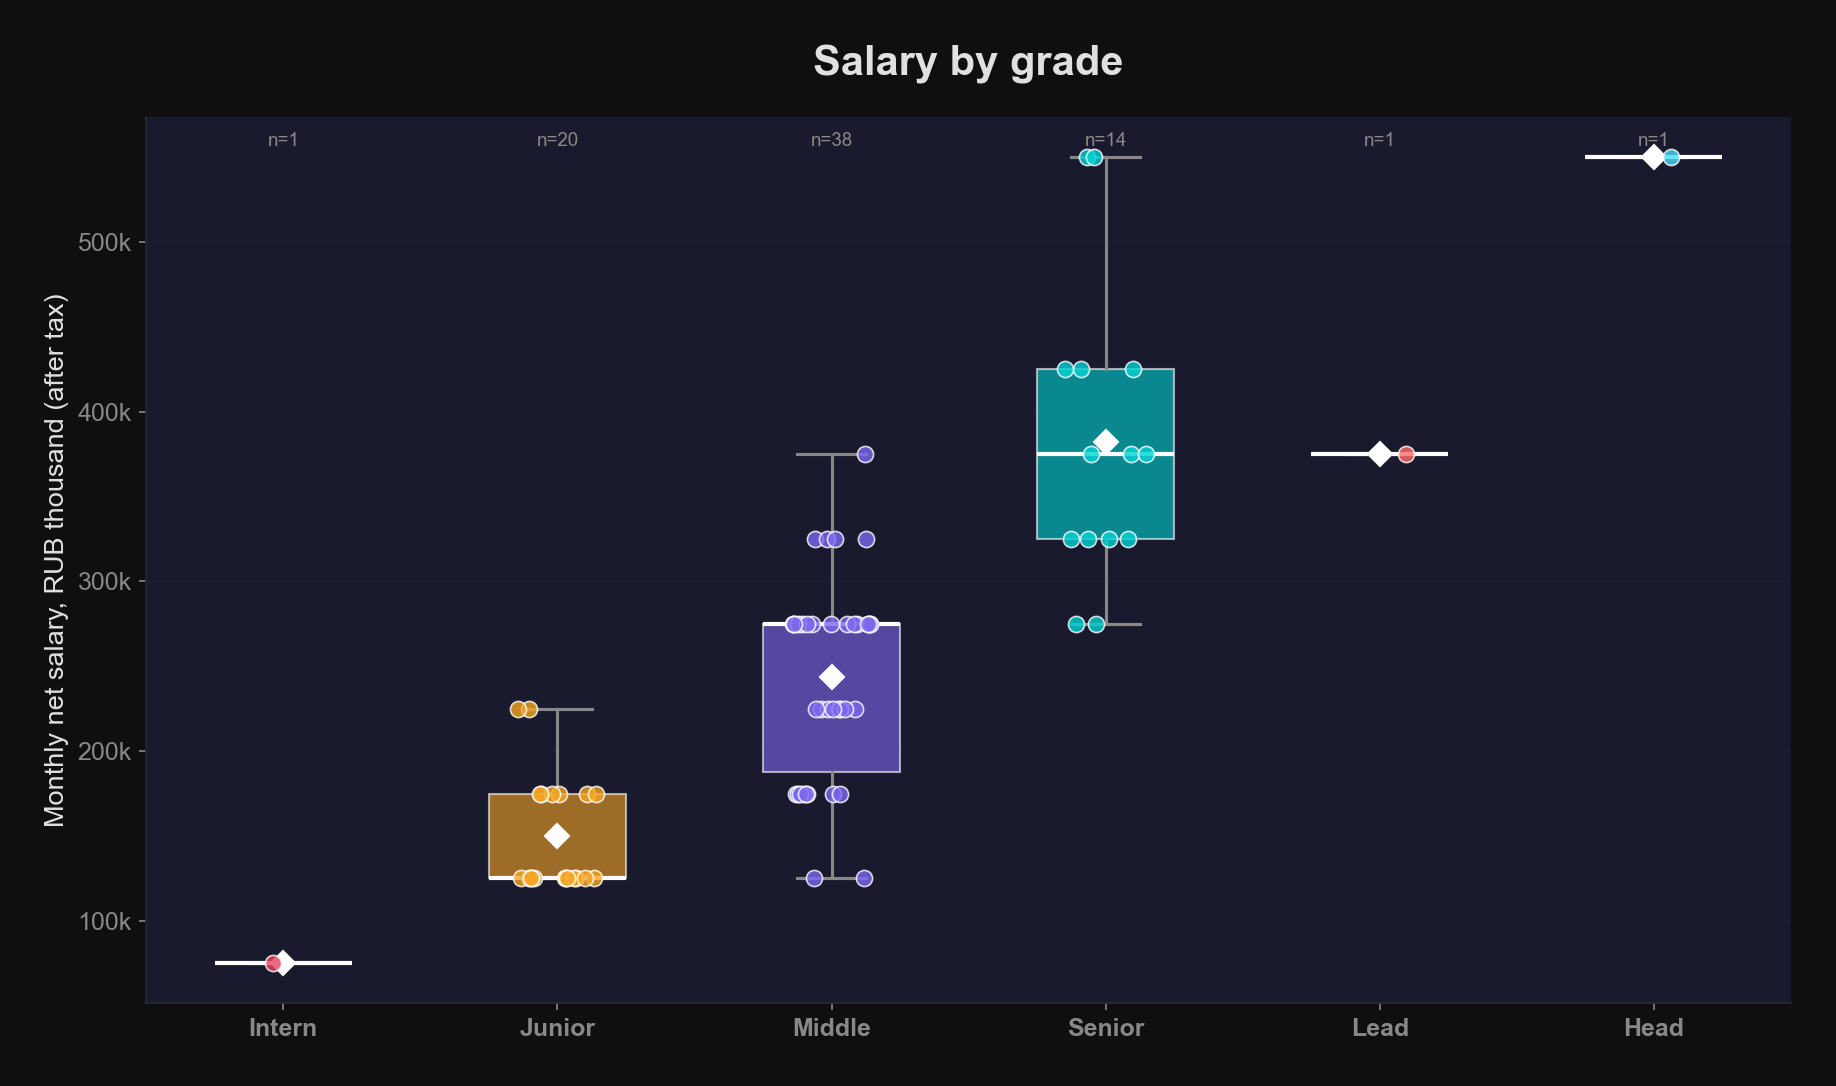

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

grades_present = [g for g in grade_order if g in df['grade'].values]
grade_colors = {g: PALETTE[i] for i, g in enumerate(grades_present)}

positions, labels, data_groups = [], [], []
for i, grade in enumerate(grades_present):
    subset = df[df['grade'] == grade]['salary_num'].dropna()
    data_groups.append(subset.values)
    positions.append(i)
    labels.append(GRADE_LABEL[grade])

bp = ax.boxplot(data_groups, positions=positions, widths=0.5, patch_artist=True,
                showfliers=False, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='white', markersize=8),
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color=TEXT_DIM, linewidth=1.5),
                capprops=dict(color=TEXT_DIM, linewidth=1.5))

for patch, grade in zip(bp['boxes'], grades_present):
    patch.set_facecolor(grade_colors[grade])
    patch.set_alpha(0.6)
    patch.set_edgecolor('white')
    patch.set_linewidth(1)

# Jittered scatter overlay
np.random.seed(42)
for i, grade in enumerate(grades_present):
    subset = df[df['grade'] == grade]['salary_num'].dropna()
    jitter = np.random.uniform(-0.15, 0.15, len(subset))
    ax.scatter(np.full(len(subset), i) + jitter, subset,
              color=grade_colors[grade], s=60, alpha=0.8,
              edgecolors='white', linewidth=0.8, zorder=3)

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax.set_ylabel('Monthly net salary, RUB thousand (after tax)', fontsize=13)
ax.set_title('Salary by grade', fontsize=20, fontweight='bold', pad=20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x)}k'))
ax.grid(axis='y', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Sample size annotation
for i, grade in enumerate(grades_present):
    n = len(df[df['grade'] == grade])
    ax.text(i, ax.get_ylim()[1] * 0.97, f'n={n}', ha='center', fontsize=9, color=TEXT_DIM)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/05_salary_by_grade.png')
plt.show()

---
## 6. Spending ladder
What people start buying as salary grows

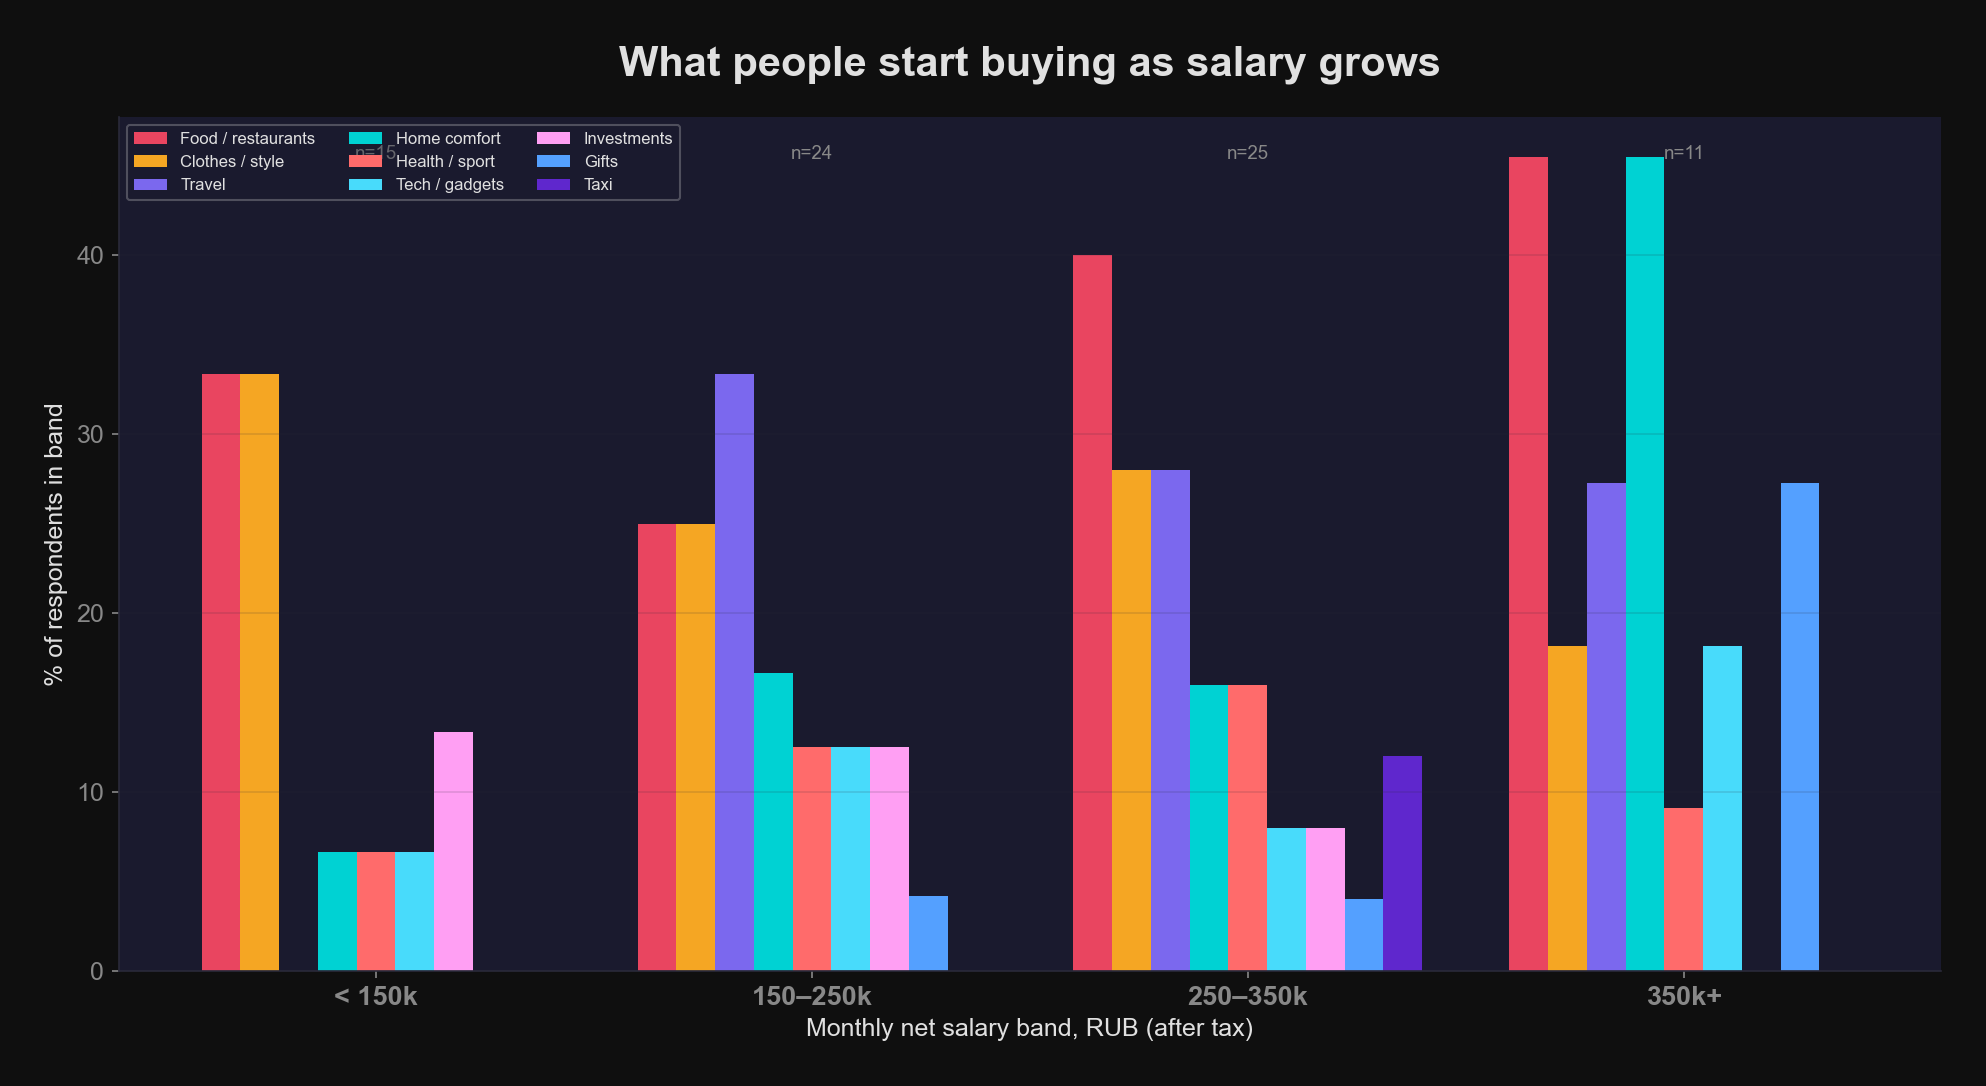

In [8]:
# Coarser salary bands
def salary_group(s):
    if s in ['<100к', '100к-150к']:
        return '< 150k'
    elif s in ['151к-200к', '201к-250к']:
        return '150–250k'
    elif s in ['251к-300к', '301к-350к']:
        return '250–350k'
    else:
        return '350k+'

df['salary_group'] = df['salary'].apply(salary_group)
sg_order = ['< 150k', '150–250k', '250–350k', '350k+']

# Keyword categorisation for free-text "new_purchases" answers.
# Categories are English labels; keyword lists remain Russian because
# respondents wrote in Russian.
categories = {
    'Food / restaurants': ['еда', 'еду', 'ресторан', 'кафе', 'доставк', 'вкусвилл', 'перекрёст',
                           'перекресток', 'продукт', 'фрукт', 'кофе', 'рацион'],
    'Travel':             ['путешеств', 'поезд', 'стран', 'отдых', 'билет'],
    'Clothes / style':    ['одежд', 'шмот', 'обувь', 'бренд', 'пальто', 'косметик', 'уход', 'бьюти'],
    'Tech / gadgets':     ['техник', 'макбук', 'ноутбук', 'айфон', 'телефон', 'дайсон', 'гаджет', 'планшет'],
    'Health / sport':     ['здоров', 'спорт', 'тренер', 'медицин', 'зуб', 'врач'],
    'Home comfort':       ['квартир', 'мебел', 'ремонт', 'клининг', 'быт'],
    'Taxi':               ['такси'],
    'Investments':        ['акци', 'откладыв', 'накоплен', 'вклад', 'инвест'],
    'Gifts':              ['подарк'],
}

def categorize(text):
    if pd.isna(text) or text.strip() in ['-', '']:
        return []
    text_lower = text.lower()
    found = [cat for cat, kws in categories.items() if any(kw in text_lower for kw in kws)]
    return found if found else ['Other']

results = {sg: Counter() for sg in sg_order}
for sg in sg_order:
    for text in df[df['salary_group'] == sg]['new_purchases']:
        for cat in categorize(text):
            results[sg][cat] += 1

# Order categories by overall frequency, drop "Other"
cat_totals = Counter()
for cc in results.values():
    cat_totals.update(cc)
all_cats = [c for c, _ in cat_totals.most_common() if c != 'Other']

fig, ax = plt.subplots(figsize=(13, 7))

x = np.arange(len(sg_order))
n_cats = len(all_cats)
width = 0.8 / n_cats

for i, cat in enumerate(all_cats):
    vals = [results[sg].get(cat, 0) for sg in sg_order]
    counts = [len(df[df['salary_group'] == sg]) for sg in sg_order]
    pcts = [v / c * 100 if c > 0 else 0 for v, c in zip(vals, counts)]
    ax.bar(x + i * width - width * n_cats / 2 + width / 2, pcts, width,
           label=cat, color=PALETTE[i % len(PALETTE)], edgecolor='none')

ax.set_xticks(x)
ax.set_xticklabels(sg_order, fontsize=13, fontweight='bold')
ax.set_xlabel('Monthly net salary band, RUB (after tax)', fontsize=12)
ax.set_ylabel('% of respondents in band', fontsize=12)
ax.set_title('What people start buying as salary grows', fontsize=20, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=8, ncol=3, framealpha=0.3)
ax.grid(axis='y', alpha=0.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, sg in enumerate(sg_order):
    n = len(df[df['salary_group'] == sg])
    ax.text(i, ax.get_ylim()[1] * 0.95, f'n={n}', ha='center', fontsize=9, color=TEXT_DIM)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/06_spending_ladder.png')
plt.show()

---
## 7. Wordcloud: "Tech purchases"
What respondents bought over the past year.

*Wordcloud terms are kept in original Russian — these are direct
phrasings from survey answers. A translated top-terms list is in `README.md`.*

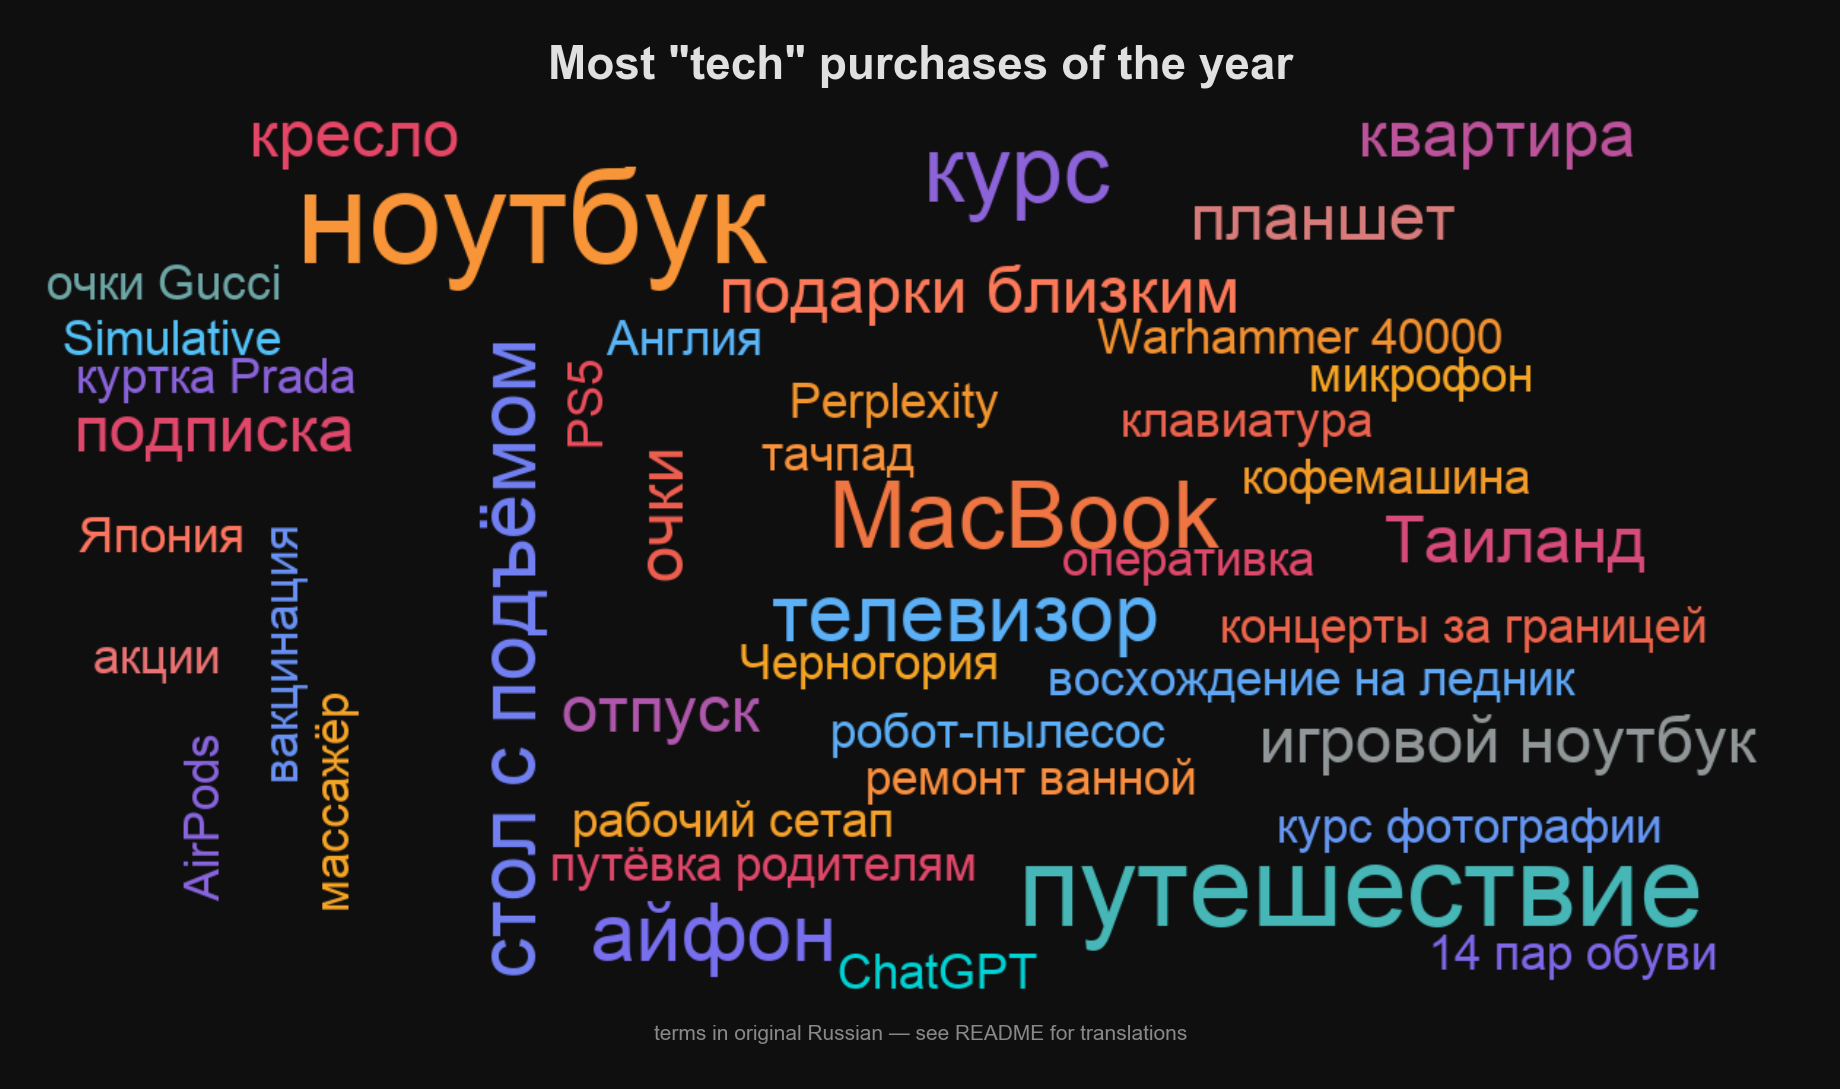

In [9]:
custom_cmap = LinearSegmentedColormap.from_list('custom',
    ['#48dbfb', '#7b68ee', '#e94560', '#f5a623', '#ff6b6b', '#00d2d3'])

# Hand-curated frequencies — each free-text answer was read and
# normalised to a canonical term.
tech_freq = {
    'ноутбук': 8, 'MacBook': 4, 'игровой ноутбук': 2,
    'айфон': 3, 'телевизор': 3, 'планшет': 2,
    'путешествие': 6, 'Япония': 1, 'Таиланд': 2,
    'Англия': 1, 'Черногория': 1, 'отпуск': 2,
    'курс': 4, 'ChatGPT': 1, 'Perplexity': 1,
    'кресло': 2, 'стол с подъёмом': 3,
    'рабочий сетап': 1, 'микрофон': 1, 'тачпад': 1, 'клавиатура': 1,
    'оперативка': 1, 'AirPods': 1,
    'квартира': 2, 'ремонт ванной': 1,
    'подарки близким': 2, 'путёвка родителям': 1,
    'вакцинация': 1, 'очки': 2, 'массажёр': 1,
    'восхождение на ледник': 1, 'концерты за границей': 1,
    'PS5': 1, 'Warhammer 40000': 1, 'курс фотографии': 1,
    'куртка Prada': 1, 'очки Gucci': 1, '14 пар обуви': 1,
    'кофемашина': 1, 'робот-пылесос': 1, 'акции': 1,
    'подписка': 2, 'Simulative': 1,
}

wc = WordCloud(
    width=1200, height=600,
    background_color='#0f0f0f',
    colormap=custom_cmap,
    font_path='/System/Library/Fonts/Supplemental/Arial.ttf',
    max_words=50,
    min_font_size=14,
    max_font_size=90,
    prefer_horizontal=0.85,
    relative_scaling=0.55,
    collocations=False,
).generate_from_frequencies(tech_freq)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most "tech" purchases of the year', fontsize=22, fontweight='bold', pad=20)
ax.text(0.5, -0.05, 'terms in original Russian — see README for translations',
        transform=ax.transAxes, ha='center', fontsize=10, color=TEXT_DIM)
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/07_wordcloud_tech.png')
plt.show()

---
## 8. Wordcloud: "What people started buying"
How consumption shifted as salary grew.

*Terms in original Russian — see README for translations.*

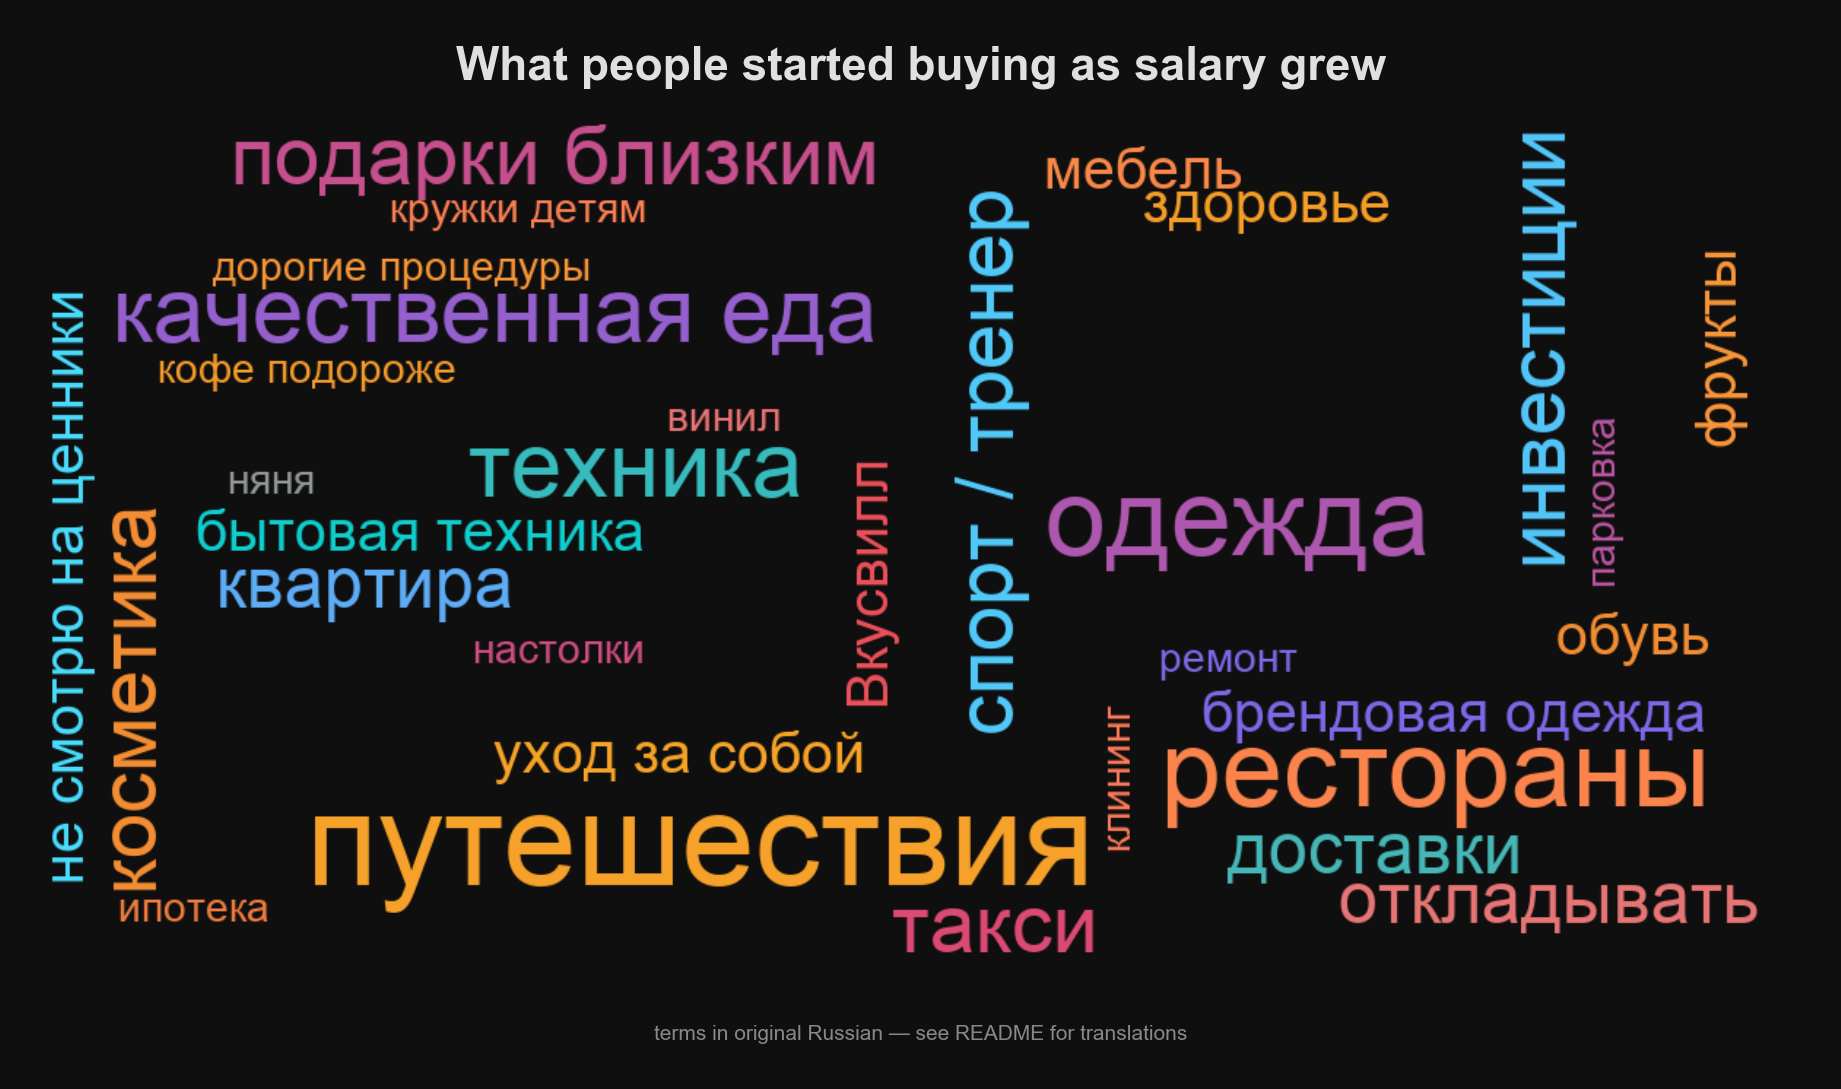

In [10]:
# Hand-curated frequencies from free-text answers
purchase_freq = {
    'путешествия': 10, 'рестораны': 7, 'одежда': 7,
    'такси': 4, 'техника': 5, 'качественная еда': 5,
    'доставки': 3, 'Вкусвилл': 2, 'кофе подороже': 1,
    'косметика': 4, 'уход за собой': 2,
    'спорт / тренер': 4, 'здоровье': 2,
    'подарки близким': 4, 'квартира': 3,
    'мебель': 2, 'бытовая техника': 2, 'клининг': 1,
    'инвестиции': 4, 'откладывать': 3,
    'обувь': 2, 'брендовая одежда': 2,
    'ипотека': 1, 'ремонт': 1,
    'фрукты': 2, 'винил': 1, 'настолки': 1,
    'дорогие процедуры': 1, 'няня': 1,
    'парковка': 1, 'кружки детям': 1,
    'не смотрю на ценники': 2,
}

wc2 = WordCloud(
    width=1200, height=600,
    background_color='#0f0f0f',
    colormap=custom_cmap,
    font_path='/System/Library/Fonts/Supplemental/Arial.ttf',
    max_words=50,
    min_font_size=14,
    max_font_size=90,
    prefer_horizontal=0.85,
    relative_scaling=0.55,
    collocations=False,
).generate_from_frequencies(purchase_freq)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc2, interpolation='bilinear')
ax.axis('off')
ax.set_title('What people started buying as salary grew', fontsize=22, fontweight='bold', pad=20)
ax.text(0.5, -0.05, 'terms in original Russian — see README for translations',
        transform=ax.transAxes, ha='center', fontsize=10, color=TEXT_DIM)
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/08_wordcloud_new_purchases.png')
plt.show()

---
## 9. Extra income by grade
Who has additional income sources

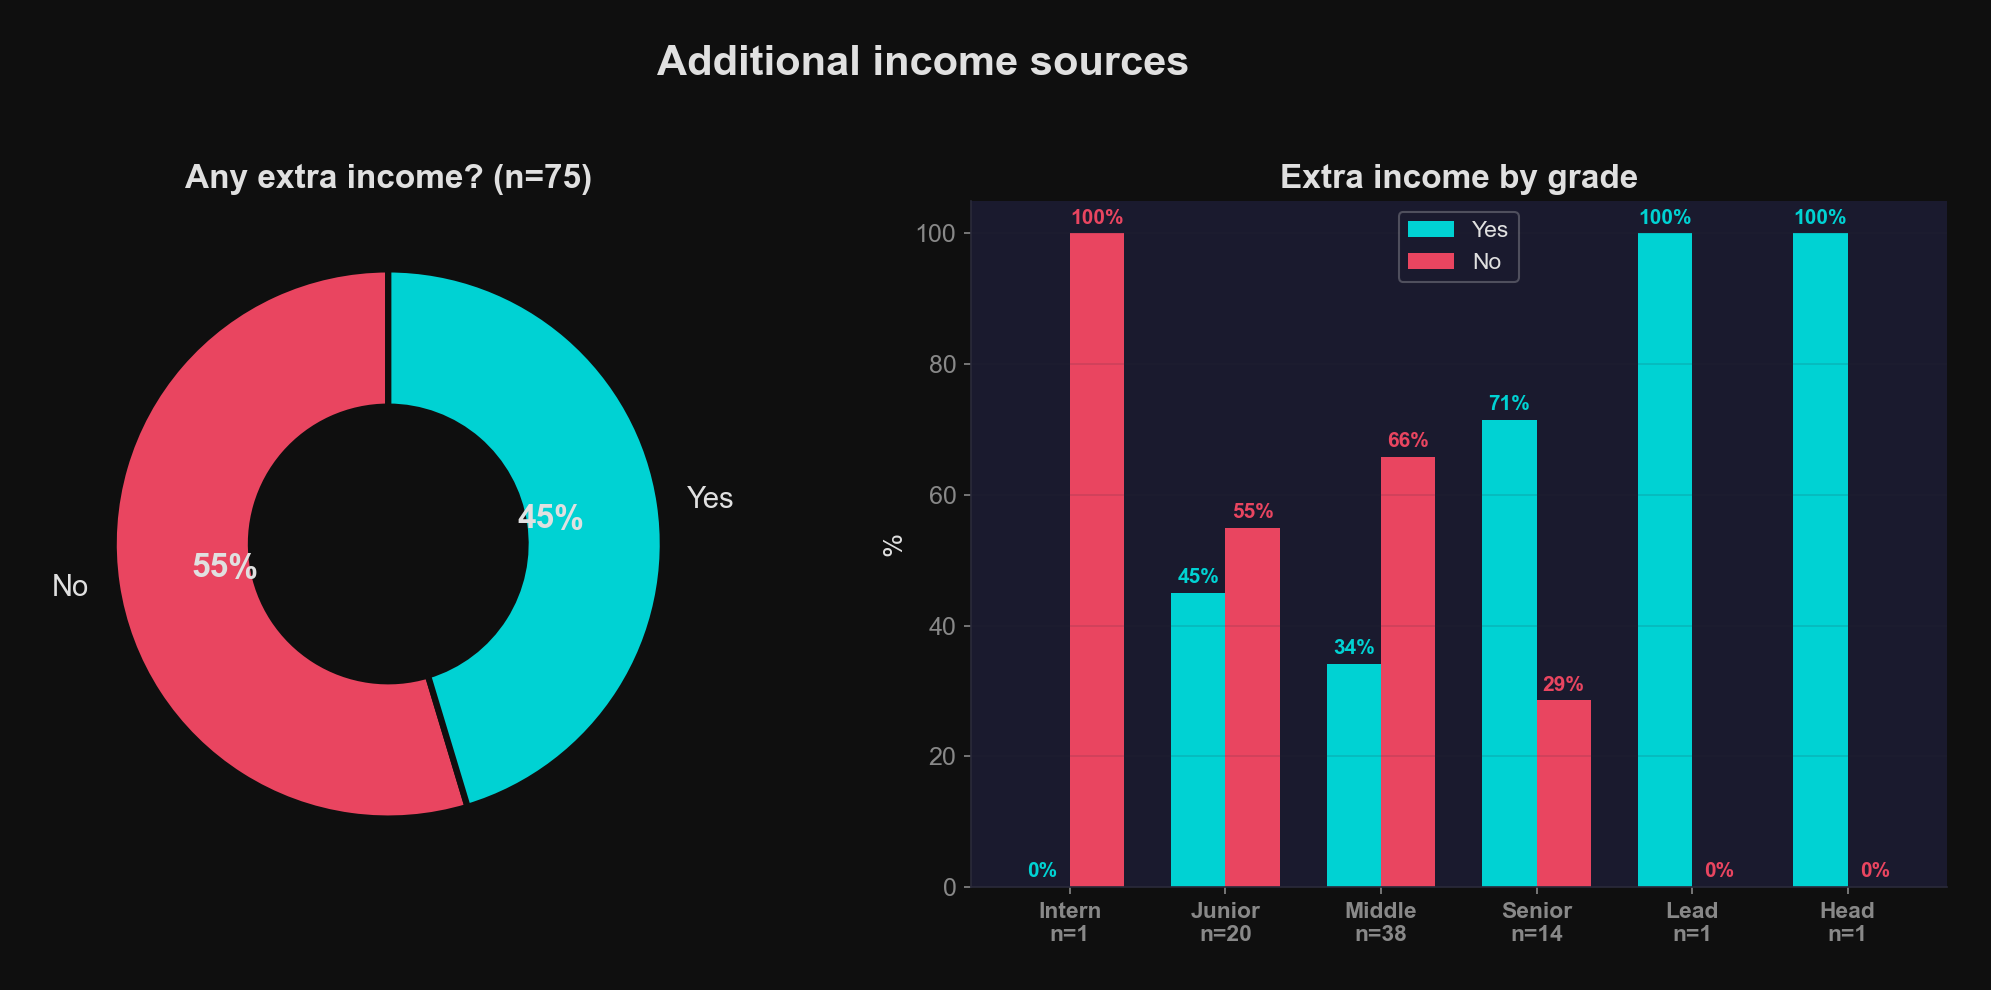

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ── Overall donut ──
extra_counts = df['extra_income'].value_counts()
labels_extra = [YESNO[v] for v in extra_counts.index]
colors_extra = [ACCENT1, '#00d2d3']
wedges, texts, autotexts = ax1.pie(
    extra_counts.values, labels=labels_extra,
    colors=colors_extra, autopct='%1.0f%%',
    startangle=90, pctdistance=0.6,
    wedgeprops=dict(width=0.5, edgecolor=BG, linewidth=3),
    textprops=dict(fontsize=14, color=TEXT)
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(16)
ax1.set_title(f'Any extra income? (n={len(df)})', fontsize=16, fontweight='bold')

# ── By grade ──
ct = pd.crosstab(df['grade_cat'], df['extra_income'], normalize='index') * 100
grades_present = [g for g in grade_order if g in ct.index]
ct = ct.loc[grades_present]
grade_counts = df['grade_cat'].value_counts()

x = np.arange(len(grades_present))
w = 0.35
if 'Да' in ct.columns:
    ax2.bar(x - w/2, ct['Да'], w, color='#00d2d3', label='Yes', edgecolor='none')
    for i, v in enumerate(ct['Да']):
        ax2.text(i - w/2, v + 1.5, f'{v:.0f}%', ha='center', fontsize=10,
                fontweight='bold', color='#00d2d3')
if 'Нет' in ct.columns:
    ax2.bar(x + w/2, ct['Нет'], w, color=ACCENT1, label='No', edgecolor='none')
    for i, v in enumerate(ct['Нет']):
        ax2.text(i + w/2, v + 1.5, f'{v:.0f}%', ha='center', fontsize=10,
                fontweight='bold', color=ACCENT1)

ax2.set_xticks(x)
ax2.set_xticklabels(
    [f'{GRADE_LABEL[g]}\nn={grade_counts.get(g, 0)}' for g in grades_present],
    fontsize=11, fontweight='bold')
ax2.set_ylabel('%', fontsize=13)
ax2.set_title('Extra income by grade', fontsize=16, fontweight='bold')
ax2.legend(fontsize=11, framealpha=0.3)
ax2.grid(axis='y', alpha=0.15)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Additional income sources', fontsize=20, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/09_extra_income.png')
plt.show()

---
## 10. Heatmap: Grade × Salary
Headcount at each intersection

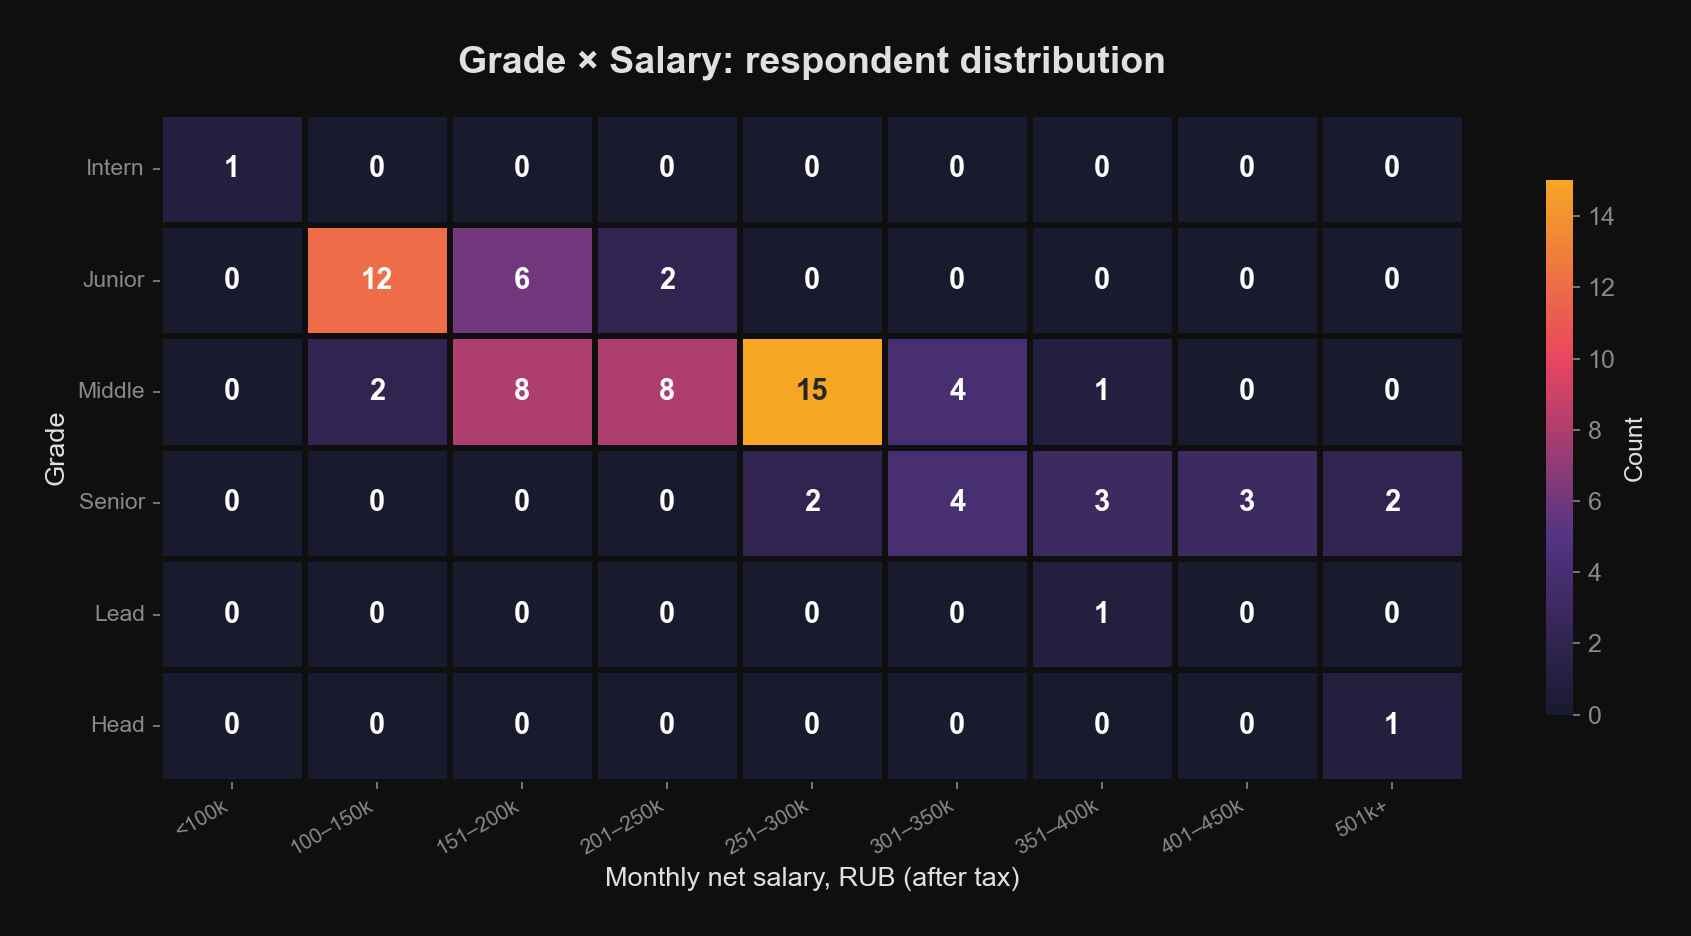

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

ct = pd.crosstab(df['grade_cat'], df['salary_cat'])
grades_present = [g for g in grade_order if g in ct.index]
sals_present = [s for s in salary_order if s in ct.columns]
ct = ct.loc[grades_present, sals_present]

heatmap_cmap = LinearSegmentedColormap.from_list(
    'hm', ['#1a1a2e', '#533483', '#e94560', '#f5a623'])

sns.heatmap(ct, annot=True, fmt='d', cmap=heatmap_cmap,
            linewidths=2, linecolor=BG, cbar_kws={'shrink': 0.8, 'label': 'Count'},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'},
            ax=ax)

ax.set_yticklabels([GRADE_LABEL[g] for g in grades_present], rotation=0, fontsize=11)
ax.set_xticklabels([SALARY_LABEL[s] for s in sals_present], rotation=30, ha='right', fontsize=10)
ax.set_xlabel('Monthly net salary, RUB (after tax)', fontsize=13)
ax.set_ylabel('Grade', fontsize=13)
ax.set_title('Grade × Salary: respondent distribution', fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/10_heatmap_grade_salary.png')
plt.show()

---
## 11. Golden quotes
The most striking answers — Russian originals on the left, English translations below each.

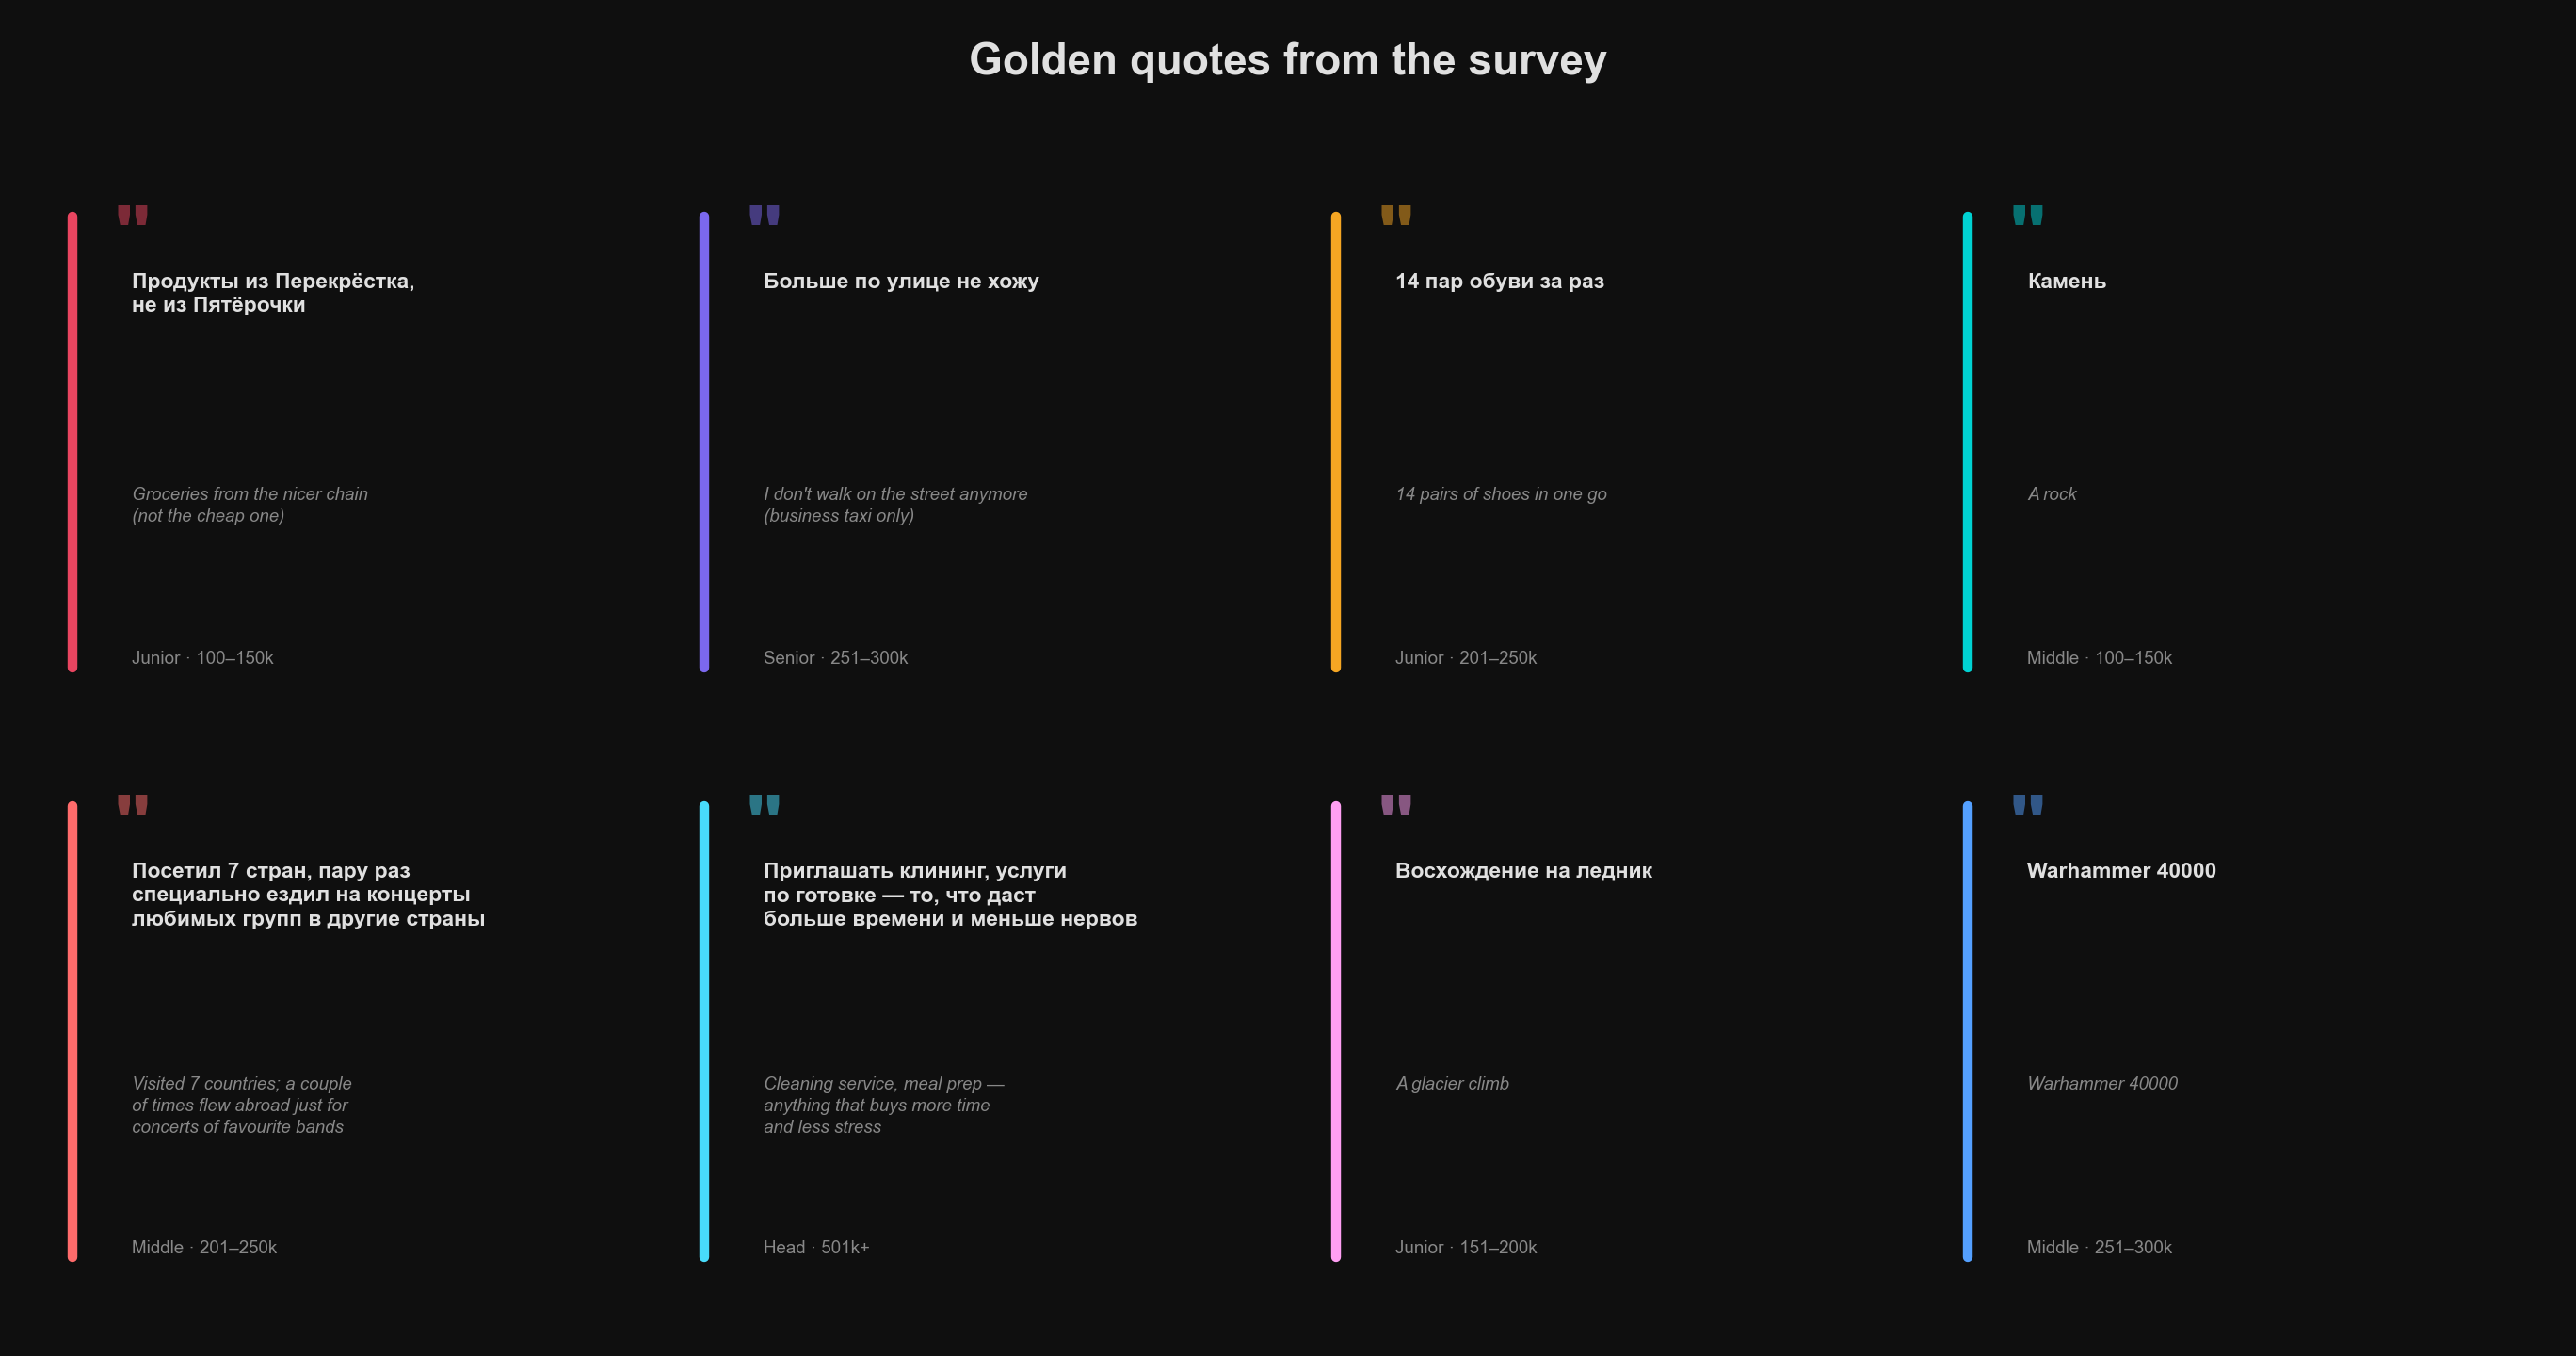

In [13]:
# (Russian original, English translation, meta, accent color)
quotes = [
    ("Продукты из Перекрёстка,\nне из Пятёрочки",
     "Groceries from the nicer chain\n(not the cheap one)",
     "Junior · 100–150k", ACCENT1),
    ("Больше по улице не хожу",
     "I don't walk on the street anymore\n(business taxi only)",
     "Senior · 251–300k", '#7b68ee'),
    ("14 пар обуви за раз",
     "14 pairs of shoes in one go",
     "Junior · 201–250k", '#f5a623'),
    ("Камень",
     "A rock",
     "Middle · 100–150k", '#00d2d3'),
    ("Посетил 7 стран, пару раз\nспециально ездил на концерты\nлюбимых групп в другие страны",
     "Visited 7 countries; a couple\nof times flew abroad just for\nconcerts of favourite bands",
     "Middle · 201–250k", '#ff6b6b'),
    ("Приглашать клининг, услуги\nпо готовке — то, что даст\nбольше времени и меньше нервов",
     "Cleaning service, meal prep —\nanything that buys more time\nand less stress",
     "Head · 501k+", '#48dbfb'),
    ("Восхождение на ледник",
     "A glacier climb",
     "Junior · 151–200k", '#ff9ff3'),
    ("Warhammer 40000",
     "Warhammer 40000",
     "Middle · 251–300k", '#54a0ff'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, (ru, en, meta, color) in enumerate(quotes):
    ax = axes[i]
    ax.set_facecolor(CARD_BG)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    ax.axvline(x=0.05, ymin=0.1, ymax=0.9, color=color, linewidth=5, solid_capstyle='round')
    ax.text(0.12, 0.92, '"', fontsize=40, fontweight='bold', color=color,
            va='top', ha='left', alpha=0.5)
    ax.text(0.15, 0.80, ru, fontsize=11, fontweight='bold', color=TEXT,
            va='top', ha='left', linespacing=1.35)
    ax.text(0.15, 0.42, en, fontsize=9, fontstyle='italic', color=TEXT_DIM,
            va='top', ha='left', linespacing=1.35)
    ax.text(0.15, 0.10, meta, fontsize=9, color=TEXT_DIM,
            va='bottom', ha='left', linespacing=1.3)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(color)
        spine.set_alpha(0.3)
        spine.set_linewidth(1)

fig.suptitle('Golden quotes from the survey', fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/11_quotes.png')
plt.show()

---
## 12. Summary statistics
Key numbers

In [14]:
print("=" * 50)
print("KEY NUMBERS")
print("=" * 50)

print(f"\nRespondents: {len(df)}")
print(f"Modal salary band: {df['salary'].mode().values[0]}")
print(f"Mean comfort score: {df['comfort'].mean():.1f} / 10")

print("\n--- 'Salary dissolves' ---")
dissolves = df['salary_dissolves'].value_counts(normalize=True) * 100
for k, v in dissolves.items():
    print(f"  {YESNO[k]}: {v:.0f}%")

print("\n--- Emergency fund ---")
has_cushion = df[df['cushion'] != 'Нет'].shape[0] / len(df) * 100
year_plus = df[df['cushion'] == '1 год +'].shape[0] / len(df) * 100
no_cushion = df[df['cushion'] == 'Нет'].shape[0] / len(df) * 100
print(f"  Has any cushion: {has_cushion:.0f}%")
print(f"  1 year or more: {year_plus:.0f}%")
print(f"  No cushion: {no_cushion:.0f}%")

print("\n--- Extra income ---")
extra = df['extra_income'].value_counts(normalize=True) * 100
for k, v in extra.items():
    print(f"  {YESNO[k]}: {v:.0f}%")

print("\n--- Top-3 expense categories ---")
top3 = Counter(all_expenses).most_common(3)
for cat, count in top3:
    label = EXPENSE_LABEL.get(cat, cat)
    print(f"  {label}: {count} mentions ({count/len(df)*100:.0f}%)")

print("\n--- Grades ---")
for g, n in df['grade'].value_counts().items():
    print(f"  {GRADE_LABEL.get(g, g)}: {n}")

print("\n--- Age ---")
print(df['age'].value_counts().to_string())

KEY NUMBERS

Respondents: 75
Modal salary band: 251к-300к
Mean comfort score: 6.3 / 10

--- 'Salary dissolves' ---
  No: 51%
  Yes: 49%

--- Emergency fund ---
  Has any cushion: 87%
  1 year or more: 20%
  No cushion: 13%

--- Extra income ---
  No: 55%
  Yes: 45%

--- Top-3 expense categories ---
  Food & restaurants: 43 mentions (57%)
  Rent: 33 mentions (44%)
  Investments / savings: 26 mentions (35%)

--- Grades ---
  Middle: 38
  Junior: 20
  Senior: 14
  Head: 1
  Intern: 1
  Lead: 1

--- Age ---
age
23-26    33
19-22    17
27-30    16
31+       9
